# Linear regression: from scratch vs. scikit-learn

Fits `LinearRegressionGD` (mini-batch gradient descent, plain numpy) and scikit-learn's own `LinearRegression` on the same preprocessed data and target, and compares them -- per `docs/superpowers/specs/2026-09-05-linear-regression-design.md`.

In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import probplot

from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import train_test_split

from ames_price.constants import NOMINAL_COLS, NUMERIC_COLS, ORDINAL_COLS
from ames_price.models.linear_regression import LinearRegressionGD
from ames_price.pipeline import build_pipeline

FEATURE_COLS = NUMERIC_COLS + ORDINAL_COLS + NOMINAL_COLS

## Load data, drop outliers, split, then fit the pipeline

`Id` 524/1299 are the two outliers flagged in `6_outliers.ipynb`. The target is `log_sale_price` (`np.log1p(SalePrice)`, decided in `1_target_variable.ipynb`) -- both models train and are scored in log space, matching the actual Kaggle metric.

The split happens *before* the pipeline is fit: `build_pipeline()` is fit only on the training split and used to `transform` the validation split, matching this project's leak-free-fitting principle (`fit()` only ever sees what it's called with). `Encoder`'s `OneHotEncoder(handle_unknown="ignore")` exists specifically so a category unseen at fit time -- e.g. a rare `Electrical` value that only appears in the validation split -- gets an all-zero one-hot row instead of leaking into how `StandardScaler` centers/scales that column.

In [2]:
df_train = pd.read_csv("../../data/train.csv")
df_train = df_train[~df_train["Id"].isin([524, 1299])]

df_feat = df_train[FEATURE_COLS]
y = np.log1p(df_train["SalePrice"]).to_numpy()

df_train_split, df_val_split, y_train, y_val = train_test_split(
    df_feat, y, test_size=0.2, random_state=42
)

pipeline = build_pipeline()
X_train = pipeline.fit_transform(df_train_split).to_numpy()
X_val = pipeline.transform(df_val_split).to_numpy()
X_train.shape, X_val.shape

((1166, 236), (292, 236))

## Fit both models on the same training split

**Hyperparameter note:** `learning_rate=0.1` (the spec's original starting value) diverges -- with 236 scaled features the mini-batch gradient overflows to `nan` within the first few epochs. Lowered to `0.01`, which converges cleanly (verified by sweeping `learning_rate` in `[0.0001, 0.03]` and `n_epochs` in `[50, 8000]`; training loss plateaus by ~300 epochs at every rate below the divergence threshold).

In [3]:
gd_model = LinearRegressionGD(
    learning_rate=0.01, batch_size=32, n_epochs=300, random_state=42
)
gd_model.fit(X_train, y_train)

sk_model = LinearRegression()
sk_model.fit(X_train, y_train)

MODELS = [("LinearRegressionGD", gd_model), ("sklearn LinearRegression", sk_model)]

## Compare on the holdout split

RMSE in log space is the metric that actually matters (matches the Kaggle scoring); RMSE in dollar space (via `expm1`) is only there for human-readable intuition. MAE is included alongside RMSE since it's more robust to the occasional large miss -- a big gap between the two would itself be a signal that a few outlier predictions are dominating RMSE. MAPE (dollar space) expresses that same error as "% of actual price" -- more informative than a flat dollar figure given how wide Ames' price range is ($34,900-$755,000 post-outlier-drop, with 7.8% of rows under $100k), where a fixed dollar error means very different things at each end.

In [4]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


for name, model in MODELS:
    preds_log = model.predict(X_val)
    preds_dollars = np.expm1(preds_log)
    actual_dollars = np.expm1(y_val)
    print(name)
    print("  RMSE (log space):", rmse(y_val, preds_log))
    print("  MAE (log space):", mean_absolute_error(y_val, preds_log))
    print("  RMSE (dollars, intuition only):", rmse(actual_dollars, preds_dollars))
    print(
        "  MAPE (dollars, % of actual price):",
        100 * mean_absolute_percentage_error(actual_dollars, preds_dollars),
    )
    print("  R^2:", r2_score(y_val, preds_log))

LinearRegressionGD
  RMSE (log space): 0.12931573704006305
  MAE (log space): 0.08941186962171428
  RMSE (dollars, intuition only): 22150.880483404893
  MAPE (dollars, % of actual price): 9.112842806224176
  R^2: 0.900801219223776
sklearn LinearRegression
  RMSE (log space): 0.13195571923534613
  MAE (log space): 0.08998273325662105
  RMSE (dollars, intuition only): 21996.366198576092
  MAPE (dollars, % of actual price): 9.12795891470964
  R^2: 0.8967095874793949


## Convergence curve

`loss_history_` is the per-epoch training MSE (log space) -- this is the actual stopping criterion for `n_epochs`: pick where this flattens, no automated tolerance check.

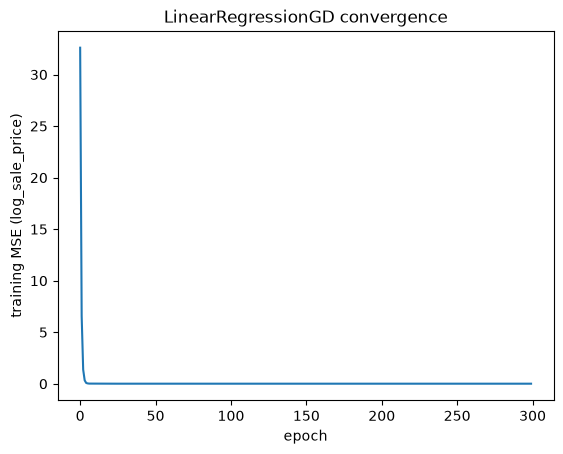

In [5]:
plt.plot(gd_model.loss_history_)
plt.xlabel("epoch")
plt.ylabel("training MSE (log_sale_price)")
plt.title("LinearRegressionGD convergence")
plt.show()

## Why `learning_rate=0.01`

The convergence curve above uses `learning_rate=0.01`. This wasn't picked
blind -- overlaying `loss_history_` for a few candidate rates over a short
window makes concrete why: too high and gradient descent overshoots and
diverges rather than converges, instead of just converging slower.

`learning_rate=0.1`'s line isn't visible below -- by epoch 0 its loss is
already ~4.5e27, far above this chart's y-axis ceiling. That's the point:
an unstable rate can blow up on the very first step, not just eventually.

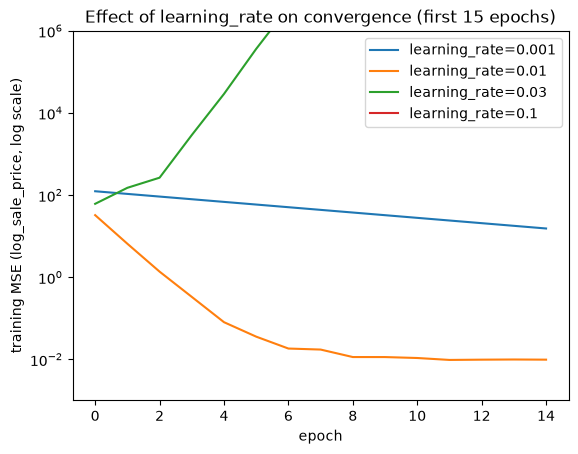

In [6]:
learning_rates = [0.001, 0.01, 0.03, 0.1]
sweep_epochs = 15

plt.figure()
for lr in learning_rates:
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)
        model = LinearRegressionGD(
            learning_rate=lr,
            batch_size=32,
            n_epochs=sweep_epochs,
            random_state=42,
        )
        model.fit(X_train, y_train)
    plt.semilogy(model.loss_history_, label=f"learning_rate={lr}")

plt.xlabel("epoch")
plt.ylabel("training MSE (log_sale_price, log scale)")
plt.ylim(1e-3, 1e6)
plt.title("Effect of learning_rate on convergence (first 15 epochs)")
plt.legend()
plt.show()

## Coefficient comparison

How close does gradient descent get to scikit-learn's closed-form (SVD-based least-squares) solution?

In [7]:
coef_diff = np.abs(gd_model.coef_ - sk_model.coef_.ravel())
print("max abs coefficient difference:", coef_diff.max())
print("intercept -- GD:", gd_model.intercept_, " sklearn:", sk_model.intercept_)

max abs coefficient difference: 0.1734591381400974
intercept -- GD: 12.023472161925982  sklearn: 12.023361623583277


## Residual diagnostics

RMSE/MAE/R^2 are single numbers -- they can't show *where* a model is
wrong. Plotting residuals (`actual - predicted`) against the predicted
value, for both models side by side, surfaces two things a scalar metric
hides: a systematic slope or curve here would mean the model
under/over-predicts at one end of the price range (bias); a funnel shape
would mean errors grow with predicted price (heteroscedasticity). A
healthy fit looks like a flat, structureless cloud centered on zero.

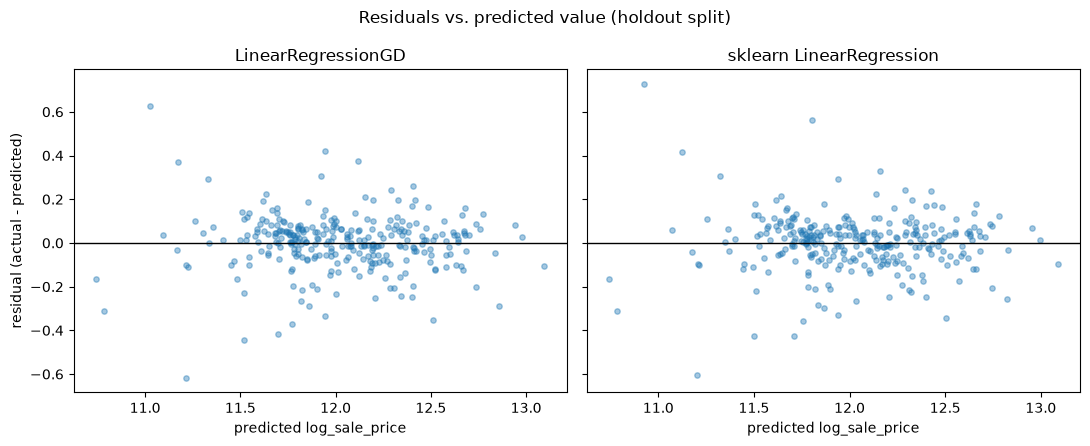

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)

for ax, (name, model) in zip(axes, MODELS, strict=True):
    preds_log = model.predict(X_val)
    residuals = y_val - preds_log
    ax.scatter(preds_log, residuals, alpha=0.4, s=15)
    ax.axhline(0, color="black", linewidth=1)
    ax.set_xlabel("predicted log_sale_price")
    ax.set_title(name)

axes[0].set_ylabel("residual (actual - predicted)")
fig.suptitle("Residuals vs. predicted value (holdout split)")
plt.tight_layout()
plt.show()

## Predicted vs. actual

Each point is one holdout row: actual `log_sale_price` (x) against the
model's prediction (y). The diagonal is `y = x` -- perfect predictions
land exactly on it, points above/below are over-/under-predictions. This
is the standard complement to the residual plot above: same information,
viewed as "how close to perfect" rather than "what's left over."

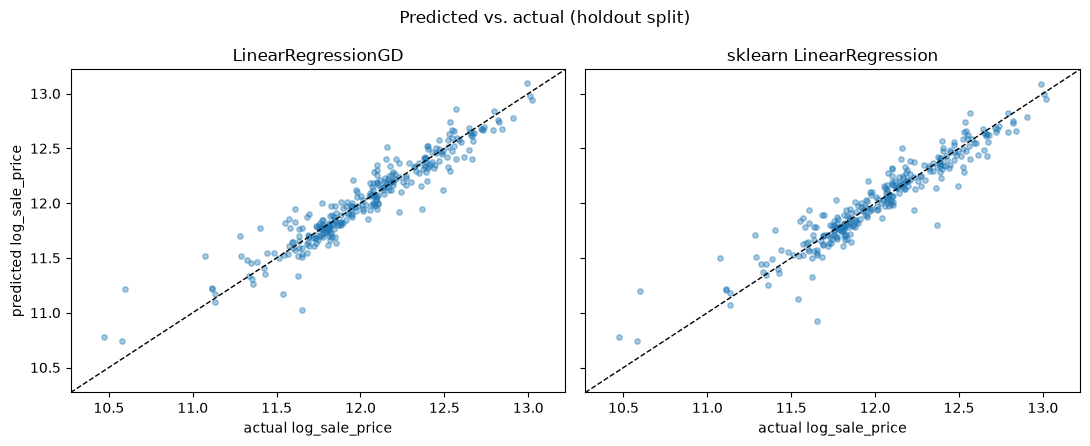

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharex=True, sharey=True)

lo = y_val.min() - 0.2
hi = y_val.max() + 0.2

for ax, (name, model) in zip(axes, MODELS, strict=True):
    preds_log = model.predict(X_val)
    ax.scatter(y_val, preds_log, alpha=0.4, s=15)
    ax.plot([lo, hi], [lo, hi], color="black", linewidth=1, linestyle="--")
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_xlabel("actual log_sale_price")
    ax.set_title(name)

axes[0].set_ylabel("predicted log_sale_price")
fig.suptitle("Predicted vs. actual (holdout split)")
plt.tight_layout()
plt.show()

## Residual normality (Q-Q plot)

A different question from the residual-vs-predicted plot above: are the
residuals themselves roughly normally distributed? This is the assumption
plain OLS confidence intervals/hypothesis tests rely on (not something
this notebook computes, but worth checking since it's the textbook
assumption for this model family). A Q-Q plot compares each residual's
quantile against what a normal distribution would predict -- points
falling on the diagonal mean "normally distributed"; curving away at the
ends means heavier/lighter tails than normal (a few larger-than-expected
misses, consistent with what the residual-vs-predicted plot already
hinted at for the cheaper end of the price range).

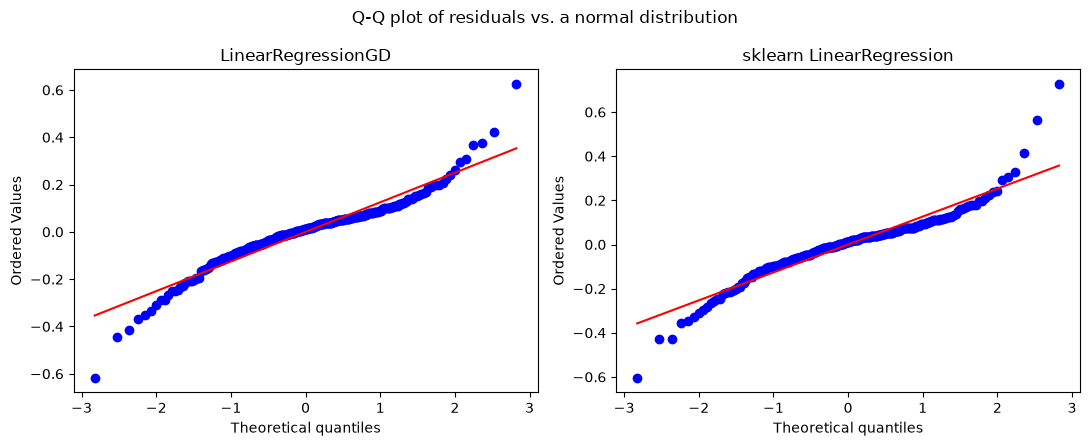

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

for ax, (name, model) in zip(axes, MODELS, strict=True):
    residuals = y_val - model.predict(X_val)
    probplot(residuals, plot=ax)
    ax.set_title(name)

fig.suptitle("Q-Q plot of residuals vs. a normal distribution")
plt.tight_layout()
plt.show()

## Summary

Both models land at essentially the same performance: RMSE around 0.13 in log space and R^2 around 0.90 on the holdout split. Coefficients, residual behavior, and Q-Q plots all agree the two are fitting the same thing.

One number is worth calling out rather than glossing over: `LinearRegressionGD` actually edges out sklearn's closed-form solution on holdout RMSE (0.1293 vs. 0.1320). This is *not* a bug, and it's *not* evidence that gradient descent is "better" in general -- it's the expected effect of GD's implicit regularization on this particular problem. `LinearRegressionGD` starts from zero-initialized weights and runs for a fixed, finite number of epochs, so it never fully reaches the same minimum-norm least-squares solution sklearn's exact SVD-based solver converges to -- especially along the design matrix's near-singular directions. This matters here because the design matrix genuinely is rank-deficient: `sk_model.rank_` is 207 out of 236 columns, a direct consequence of one-hot encoding without `drop="first"`. Along those near-singular directions, partial convergence acts like a mild, free regularizer, which is why it can (slightly) outperform the exact solution on this split. It's a property of this rank-deficient setup and this training budget, not a general claim that GD beats OLS -- training `LinearRegressionGD` to full convergence would erase the gap (and likely the sign of it).